
# DBpedia Ontology Classification - LSTM - Jesus David Gelves Cajiao - 30000098650


In [1]:

# ============================================================================
# DBpedia Ontology Clasificacion LSTM - Kaggle Dataset
# Copyright:
#   Jesus David Gelves Cajiao - 3000098650
# ============================================================================
# Dependencias
#!pip install -q kagglehub[pandas-datasets] tensorflow scikit-learn pandas matplotlib seaborn --upgrade

import os, sys, math, json, random, gc, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [2]:

# Configuración principal
DATASET_SLUG = "thedevastator/dbpedia-ontology-dataset"
TRAIN_FILE   = "train.csv"
TEST_FILE    = "test.csv"

# Proporciones y recursos
VAL_SIZE          = 0.15
SUBSAMPLE_TRAIN   = None
MAX_LEN           = 1000
VOCAB_SIZE        = 120
EMBED_DIM         = 64
LSTM_UNITS        = 128
BATCH_SIZE        = 512
EPOCHS            = 13
SEED              = 42

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# Columnas probables por si cambian los nombres en el dataset
TEXT_CANDIDATES   = [
    ("title","content"),
    ("Title","Content"),
    ("text",),
    ("Text",),
    ("content",),
    ("Content",),
]
LABEL_CANDIDATES  = ["label","Label","class","Class","category","Category"]

# Directorio local alternativo
LOCAL_DATA_DIR = "./dbpedia_local"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)


In [3]:

# Carga de datos con KaggleHub (fallback a ruta local si falla)
def try_load_with_kagglehub(dataset_slug: str, file_path: str):
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        print(f"Intentando cargar con KaggleHub: {dataset_slug} :: {file_path}")
        df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            dataset_slug,
            file_path,
        )
        return df
    except Exception as e:
        print("KaggleHub no disponible o falló la carga:", e)
        return None

def try_load_local(file_path: str):
    p = os.path.join(LOCAL_DATA_DIR, file_path)
    if os.path.exists(p):
        print(f"📄 Cargando local: {p}")
        return pd.read_csv(p)
    else:
        print(f"No se encontró local: {p}")
        return None

df_train = try_load_with_kagglehub(DATASET_SLUG, TRAIN_FILE)
if df_train is None:
    df_train = try_load_local(TRAIN_FILE)

df_test  = try_load_with_kagglehub(DATASET_SLUG, TEST_FILE)
if df_test is None:
    df_test = try_load_local(TEST_FILE)

if df_train is None or df_test is None:
    raise RuntimeError(
        "No se pudo cargar el dataset. "
        "Opciones:\n"
        "1) Instala/Configura kagglehub y vuelve a ejecutar.\n"
        "2) Descarga manualmente los CSV y colócalos en ./dbpedia_local/"
    )

print("Train shape:", df_train.shape, "| Test shape:", df_test.shape)
display(df_train.head())


Intentando cargar con KaggleHub: thedevastator/dbpedia-ontology-dataset :: train.csv


/tmp/ipython-input-2044201831.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 58.9M/58.9M [00:04<00:00, 15.2MB/s]

Extracting zip of train.csv...


Intentando cargar con KaggleHub: thedevastator/dbpedia-ontology-dataset :: test.csv


/tmp/ipython-input-2044201831.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 7.37M/7.37M [00:01<00:00, 5.39MB/s]

Extracting zip of test.csv...


Train shape: (560000, 3) | Test shape: (70000, 3)


,label,title,content
0,0,E. D. Abbott Ltd,Abbott of Farnham E D Abbott Limited was a Br...
1,0,Schwan-Stabilo,Schwan-STABILO is a German maker of pens for ...
2,0,Q-workshop,Q-workshop is a Polish company located in Poz...
3,0,Marvell Software Solutions Israel,Marvell Software Solutions Israel known as RA...
4,0,Bergan Mercy Medical Center,Bergan Mercy Medical Center is a hospital loc...


In [4]:

# Detección de columnas de texto/etiqueta y preprocesamiento
def find_label_column(df: pd.DataFrame):
    cols = list(df.columns)
    for c in LABEL_CANDIDATES:
        if c in cols:
            return c
    nunique = df.nunique()
    candidate = nunique.sort_values().index[0]
    print(f"usando '{candidate}' como columna de etiqueta.")
    return candidate

def find_text_columns(df: pd.DataFrame):
    cols = set(df.columns)
    for cand in TEXT_CANDIDATES:
        if all(c in cols for c in cand):
            return list(cand)
    # fallback: intenta detectar campos de texto largos
    object_cols = [c for c in df.columns if df[c].dtype == 'object']
    if object_cols:
        return [object_cols[0]]
    raise ValueError("No se encontraron columnas de texto válidas")

label_col = find_label_column(df_train)
text_cols = find_text_columns(df_train)
print("→ label_col:", label_col)
print("→ text_cols:", text_cols)

def build_text(df: pd.DataFrame, text_cols):
    parts = []
    for c in text_cols:
        parts.append(df[c].fillna("").astype(str))
    text = parts[0]
    for p in parts[1:]:
        text = text + " " + p
    return text

df_train = df_train.copy()
df_test  = df_test.copy()

df_train["text"] = build_text(df_train, text_cols)
df_test["text"]  = build_text(df_test, text_cols)

# Limpieza básica
def clean_text(s: pd.Series) -> pd.Series:
    # sin excesos: bajamos a minúscula, colapsamos espacios
    s = s.str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    return s

df_train["text"] = clean_text(df_train["text"])
df_test["text"]  = clean_text(df_test["text"])

# Asegurar etiquetas numéricas 0..(num_classes-1)
y_train_raw = df_train[label_col]
y_test_raw  = df_test[label_col]

if not np.issubdtype(y_train_raw.dtype, np.number):
    y_train, uniques = pd.factorize(y_train_raw)
    mapping = {int(i): str(lbl) for i, lbl in enumerate(uniques)}
    # map test con el mismo vocabulario (desconocidos -> -1)
    y_test = pd.Series(df_test[label_col]).map({v:k for k,v in mapping.items()}).fillna(-1).astype(int).values
else:
    # si ya son números, reindexamos de 0..K-1 por orden ascendente de clases únicas
    classes_sorted = np.sort(df_train[label_col].unique())
    remap = {int(v): int(i) for i, v in enumerate(classes_sorted)}
    mapping = {int(i): str(v) for i, v in enumerate(classes_sorted)}
    y_train = df_train[label_col].map(remap).values
    y_test  = df_test[label_col].map(remap).values

num_classes = len(set(y_train))
print(f"Clases: {num_classes} -> {mapping}")

id_to_name = { # Estos id salen directamente de una fuente del dataset https://emilhvitfeldt.github.io/textdata/reference/dataset_dbpedia.html
  0: "Company",
  1: "Educational Institution",
  2: "Artist",
  3: "Athlete",
  4: "OfficeHolder",
  5: "MeanOfTransportation",
  6: "Building",
  7: "NaturalPlace",
  8: "Village",
  9: "Animal",
  10: "Plant",
  11: "Album",
  12: "Film",
  13: "Written Work"
}

print("\nCLASES DISPONIBLES (DBpedia) :")
id_to_name = {i: name for i, name in mapping.items()}
for i in range(len(id_to_name)):
    print(f"{i:>2} → {id_to_name[i]}")



→ label_col: label
→ text_cols: ['title', 'content']
Clases: 14 -> {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '10', 11: '11', 12: '12', 13: '13'}

CLASES DISPONIBLES (DBpedia) :
 0 → 0
 1 → 1
 2 → 2
 3 → 3
 4 → 4
 5 → 5
 6 → 6
 7 → 7
 8 → 8
 9 → 9
10 → 10
11 → 11
12 → 12
13 → 13


In [5]:

# Submuestreo opcional para entrenar rápido
if SUBSAMPLE_TRAIN is not None and SUBSAMPLE_TRAIN < len(df_train):
    df_train = df_train.sample(SUBSAMPLE_TRAIN, random_state=SEED)
    y_train  = y_train[df_train.index]

print("Train (post-subsample):", df_train.shape)

# Stratified split
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    df_train["text"].values, y_train, test_size=VAL_SIZE, stratify=y_train, random_state=SEED
)

X_te = df_test["text"].values
y_te = y_test

print("Split sizes -> train:", len(X_tr), "| val:", len(X_val), "| test:", len(X_te))


Train (post-subsample): (560000, 4)
Split sizes -> train: 476000 | val: 84000 | test: 70000


In [6]:

# Vectorización a nivel de carácter
text_vec = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize="lower_and_strip_punctuation",
    split="character",
    output_mode="int",
    output_sequence_length=MAX_LEN,
    name="char_vectorizer"
)

# Adaptar sobre el corpus de entrenamiento
text_vec.adapt(tf.data.Dataset.from_tensor_slices(X_tr).batch(1024))
vocab = text_vec.get_vocabulary()
print("Vocab size (incl. OOV/blank):", len(vocab))
print("Sample vocab:", vocab[:50])

# Datasets de tf.data (entregan cadenas de texto; el vectorizador es parte del modelo)
def make_ds(texts, labels=None, training=False):
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(texts)
        ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
        return ds
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if training:
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

ds_tr  = make_ds(X_tr, y_tr, training=True)
ds_val = make_ds(X_val, y_val, training=False)
ds_te  = make_ds(X_te, y_te, training=False)


Vocab size (incl. OOV/blank): 120
Sample vocab: ['', '[UNK]', np.str_(' '), np.str_('e'), np.str_('a'), np.str_('i'), np.str_('n'), np.str_('t'), np.str_('o'), np.str_('s'), np.str_('r'), np.str_('l'), np.str_('h'), np.str_('d'), np.str_('c'), np.str_('m'), np.str_('u'), np.str_('f'), np.str_('p'), np.str_('b'), np.str_('g'), np.str_('y'), np.str_('w'), np.str_('v'), np.str_('k'), np.str_('1'), np.str_('0'), np.str_('9'), np.str_('2'), np.str_('j'), np.str_('z'), np.str_('8'), np.str_('3'), np.str_('6'), np.str_('5'), np.str_('7'), np.str_('4'), np.str_('x'), np.str_('q'), np.str_('–'), np.str_('ā'), np.str_('é'), np.str_('ó'), np.str_('ا'), np.str_('ˈ'), np.str_('ł'), np.str_('\u200e'), np.str_('á'), np.str_('а'), np.str_('и')]


In [9]:

# Modelo LSTM (char-level)
def build_model(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, num_classes= num_classes):
    inputs = layers.Input(shape=(1,), dtype=tf.string, name="text")
    x = text_vec(inputs)
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)(x)
    x = layers.Bidirectional(layers.LSTM(192, return_sequences=True))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs=inputs, outputs=outputs, name="dbpedia_char_lstm")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()


Model: "dbpedia_char_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 1000)      │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1000, 64)  │      7,680 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 1000)      │          0 │ char_vectorizer[… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 1000, 384) │    394,752 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1000, 384) │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 256)       │    525,312 │ dropout_3[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 14)        │      3,598 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 997,134 (3.80 MB)

 Trainable params: 997,134 (3.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/13
600/600 ━━━━━━━━━━━━━━━━━━━━ 423s 694ms/step - accuracy: 0.3587 - loss: 1.8341 - val_accuracy: 0.6773 - val_loss: 0.8949 - learning_rate: 0.0010
Epoch 2/13
330/600 ━━━━━━━━━━━━━━━━━━━━ 2:55 651ms/step - accuracy: 0.6684 - loss: 0.9298

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


600/600 ━━━━━━━━━━━━━━━━━━━━ 239s 398ms/step - accuracy: 0.6762 - loss: 0.9092 - val_accuracy: 0.7232 - val_loss: 0.7684 - learning_rate: 0.0010
Epoch 3/13
600/600 ━━━━━━━━━━━━━━━━━━━━ 415s 692ms/step - accuracy: 0.7654 - loss: 0.6865 - val_accuracy: 0.8374 - val_loss: 0.5068 - learning_rate: 0.0010
Epoch 4/13
600/600 ━━━━━━━━━━━━━━━━━━━━ 239s 397ms/step - accuracy: 0.8537 - loss: 0.4619 - val_accuracy: 0.9029 - val_loss: 0.3058 - learning_rate: 0.0010
Epoch 5/13
600/600 ━━━━━━━━━━━━━━━━━━━━ 415s 692ms/step - accuracy: 0.9131 - loss: 0.2844 - val_accuracy: 0.9321 - val_loss: 0.2200 - learning_rate: 0.0010
Epoch 6/13
600/600 ━━━━━━━━━━━━━━━━━━━━ 239s 398ms/step - accuracy: 0.9436 - loss: 0.1900 - val_accuracy: 0.9558 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 7/13
600/600 ━━━━━━━━━━━━━━━━━━━━ 415s 692ms/step - accuracy: 0.9558 - loss: 0.1486 - val_accuracy: 0.9675 - val_loss: 0.1125 - learning_rate: 0.0010
Epoch 8/13
600/600 ━━━━━━━━━━━━━━━━━━━━ 239s 398ms/step - accuracy: 0.9661 

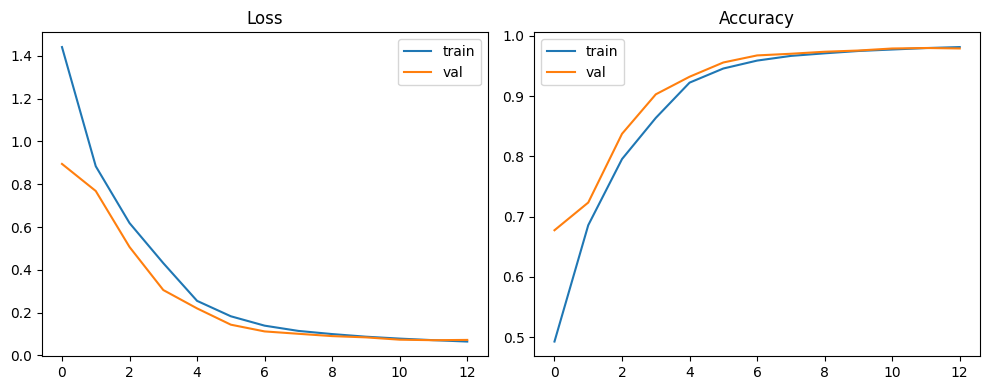

In [10]:

# Entrenamiento
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    ds_tr,
    validation_data=ds_val,
    epochs=EPOCHS,
    steps_per_epoch=600,
    validation_steps=100,
    callbacks=callbacks,
    verbose=1
)


# Curvas
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(history.history["loss"]); plt.plot(history.history["val_loss"]); plt.title("Loss"); plt.legend(["train","val"])
plt.subplot(1,2,2); plt.plot(history.history["accuracy"]); plt.plot(history.history["val_accuracy"]); plt.title("Accuracy"); plt.legend(["train","val"])
plt.tight_layout(); plt.show()


Test Loss: 0.0731  |  Test Acc: 0.9801
              precision    recall  f1-score   support

           0     0.9300    0.9648    0.9471      5000
           1     0.9834    0.9822    0.9828      5000
           2     0.9537    0.9810    0.9672      5000
           3     0.9926    0.9864    0.9895      5000
           4     0.9797    0.9670    0.9733      5000
           5     0.9865    0.9800    0.9832      5000
           6     0.9713    0.9626    0.9670      5000
           7     0.9862    0.9888    0.9875      5000
           8     0.9974    0.9970    0.9972      5000
           9     0.9800    0.9876    0.9838      5000
          10     0.9919    0.9808    0.9863      5000
          11     0.9914    0.9898    0.9906      5000
          12     0.9917    0.9850    0.9884      5000
          13     0.9880    0.9678    0.9778      5000

    accuracy                         0.9801     70000
   macro avg     0.9803    0.9801    0.9801     70000
weighted avg     0.9803    0.9801    0.98

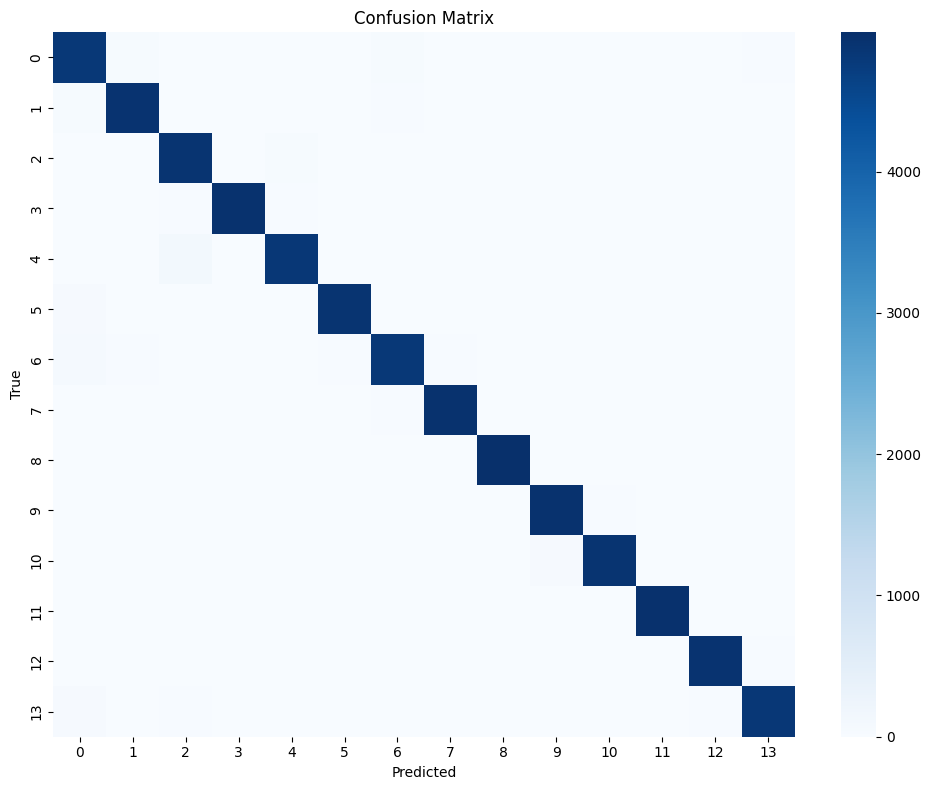

In [11]:

# Evaluación
test_loss, test_acc = model.evaluate(ds_te, verbose=0)
print(f"Test Loss: {test_loss:.4f}  |  Test Acc: {test_acc:.4f}")

# Predicciones y métricas extendidas
from sklearn.metrics import classification_report, confusion_matrix
y_prob = model.predict(ds_te, verbose=0)
y_pred = y_prob.argmax(axis=1)

# Target names a partir del mapping
target_names = [mapping[i] if i in mapping else str(i) for i in range(num_classes)]
print(classification_report(y_te, y_pred, labels=list(range(num_classes)), target_names=target_names, digits=4))

cm = confusion_matrix(y_te, y_pred, labels=list(range(num_classes)))
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()


In [12]:

# Metodo para probar la prediccion
def predict_texts(texts, k=3):
    ds = make_ds(np.array(texts))
    probs = model.predict(ds, verbose=0)
    preds = probs.argmax(axis=1)
    out = []
    for i, t in enumerate(texts):
        cls = preds[i]
        topk = probs[i].argsort()[::-1][:k]
        out.append({
            "text": t[:200] + ("..." if len(t)>200 else ""),
            "pred": target_names[cls],
            "topk": [(target_names[j], float(probs[i][j])) for j in topk]
        })
    return out

examples = [
    "Microsoft Corporation is an American multinational technology company.",
    "Albert Einstein was a German-born theoretical physicist who developed the theory of relativity.",
    "The Beatles were an English rock band formed in Liverpool in 1960.",
    "Lionel Messi is an Argentine professional footballer who plays as a forward.",
    "Harvard University is a private Ivy League research university in Cambridge, Massachusetts.",
    "Mount Everest is Earth's highest mountain above sea level.",
    "Inception is a 2010 science fiction action film written and directed by Christopher Nolan."
]

print("\nEJEMPLOS PARA LA PREDICCIÓN:")
for r in predict_texts(examples):
    print(f"\nTexto: {r['text']}")
    print(f"Predicción principal: {r['pred']}")
    print("Top 3 probabilidades:")
    for cls, prob in r['topk']:
        print(f"   - {cls}: {prob:.3f}")



EJEMPLOS PARA LA PREDICCIÓN:

Texto: Microsoft Corporation is an American multinational technology company.
Predicción principal: 0
Top 3 probabilidades:
   - 0: 0.998
   - 6: 0.000
   - 10: 0.000

Texto: Albert Einstein was a German-born theoretical physicist who developed the theory of relativity.
Predicción principal: 2
Top 3 probabilidades:
   - 2: 0.812
   - 4: 0.177
   - 0: 0.006

Texto: The Beatles were an English rock band formed in Liverpool in 1960.
Predicción principal: 0
Top 3 probabilidades:
   - 0: 0.415
   - 13: 0.242
   - 11: 0.147

Texto: Lionel Messi is an Argentine professional footballer who plays as a forward.
Predicción principal: 3
Top 3 probabilidades:
   - 3: 0.999
   - 2: 0.001
   - 4: 0.000

Texto: Harvard University is a private Ivy League research university in Cambridge, Massachusetts.
Predicción principal: 1
Top 3 probabilidades:
   - 1: 0.996
   - 0: 0.003
   - 6: 0.001

Texto: Mount Everest is Earth's highest mountain above sea level.
Predicción princi